# Pictures dataset

This notebook retrieves free pictures from Pexels to build the mozayc demonstration examples.

In [1]:
from pathlib import Path
import requests
from PIL import Image, ImageOps

from mosayc import load_cfg
cfg = load_cfg()

In [2]:
main_path = Path(r"../../pictures")
tiles_path = main_path / "tiles"
original_url = "https://images.pexels.com/photos/1269968/pexels-photo-1269968.jpeg"
original_path = main_path / "original.jpeg"
pexels_request = "multicolored abstract painting"

## Target picture:

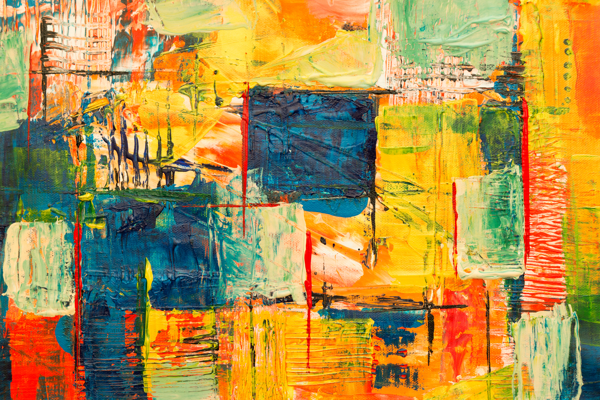

In [3]:
with open(original_path, 'wb') as f:
    f.write(requests.get(original_url).content)

display(ImageOps.exif_transpose(Image.open(original_path)).resize( (600, 400) ))

## Tiles

In [4]:
from pexels_api import API
api = API(cfg['pexels']['key'])
session = requests.Session()

In [5]:
for i in range(1, 3):
    api.search(pexels_request, results_per_page=80, page=i)
    photos = api.get_entries()
    for photo in photos:
        url = photo.medium
        path = tiles_path / f"{photo.id}.jpeg"
        with open(path, 'wb') as f:
            f.write(session.get(url).content)